# Recommendation System - Content Based Filtering
## This notebook outlines the concepts involved in Content Based Filtering Recommendation System

Dataset: 
- https://raw.githubusercontent.com/subashgandyer/datasets/main/restaurant_data/restaurants.csv

### Steps
- Import the necessary libraries
- Load the dataset
- Prepare the dataset
- Compute similarity scores between restaurants
    - Use TfidfVectorizer
- Recommend top X restaurants for a specific cuisine in some location

### Import the necessary libraries

In [1]:
import numpy as np 
import pandas as pd 
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel
from nltk.tokenize import word_tokenize
import seaborn as sns
import matplotlib.pyplot as plt

### Load the dataset

In [4]:
data = pd.read_csv('restaurants.csv', encoding ='latin1')

### Prepare and Explore the dataset
#### Find out how many restaurants in each city

In [7]:
data['City'].value_counts(dropna = False)

City
New Delhi           5473
Gurgaon             1118
Noida               1080
Faridabad            251
Ghaziabad             25
                    ... 
Panchkula              1
Mc Millan              1
Mayfield               1
Macedon                1
Vineland Station       1
Name: count, Length: 141, dtype: int64

#### Collect a specific city data

In [9]:
data_city = data.loc[data['City'] == 'New Delhi']

#### Collect 'Restaurant Name','Cuisines','Locality','Aggregate rating'

In [12]:
data_new_delphi=data_city[['Restaurant Name','Cuisines','Locality','Aggregate rating']]

#### Find how many restaurants in a specific locality in the chosen city

In [14]:
data_new_delphi['Locality'].value_counts(dropna = False).head(5)

Locality
Connaught Place    122
Rajouri Garden      99
Shahdara            87
Defence Colony      86
Pitampura           85
Name: count, dtype: int64

In [18]:
data_new_delphi

,Restaurant Name,Cuisines,Locality,Aggregate rating
2560,Food Cloud,Cuisine Varies,Aaya Nagar,0.0
2561,Burger.in,Fast Food,Adchini,3.2
2562,Days of the Raj,"North Indian, Seafood, Continental",Adchini,3.4
2563,Dilli Ka Dhaba,"South Indian, North Indian",Adchini,2.6
2564,Govardhan,"South Indian, North Indian, Chinese",Adchini,3.4
...,...,...,...,...
8028,Motu N Patlu,"Lebanese, North Indian, Fast Food",Zakir Nagar,0.0
8029,S.K. Fast Food,Chinese,Zakir Nagar,0.0
8030,Sufiyan Restaurant,Mughlai,Zakir Nagar,0.0
8031,The Relax Point,North Indian,Zakir Nagar,0.0


#### List the restaurants in that locality

In [16]:
data_new_delphi.loc[data['Locality'] == 'Connaught Place']

,Restaurant Name,Cuisines,Locality,Aggregate rating
2999,Amber,"North Indian, Chinese, Mughlai",Connaught Place,2.6
3000,Attitude Kitchen & Bar,"North Indian, Continental, Italian",Connaught Place,2.9
3001,Cafe Coffee Day,Cafe,Connaught Place,3.4
3002,Castle 9,"Finger Food, Continental, North Indian, Chinese",Connaught Place,3.1
3003,Costa Coffee,Cafe,Connaught Place,3.4
...,...,...,...,...
3116,United Coffee House,"North Indian, European, Asian, Mediterranean",Connaught Place,4.1
3117,Unplugged Courtyard,"North Indian, Continental",Connaught Place,4.0
3118,Wenger's Deli,"Bakery, Desserts, Fast Food",Connaught Place,4.3
3119,Wenger's,"Bakery, Fast Food, Desserts",Connaught Place,4.3


### Computing Similarity score between restaurants
**Steps to follow** :
1. Data consist of the only location
2. Reset index for cosine similarity because the Cosine similarity index has to be same value with the result of TF-IDF vectorizer
3. Feature Extraction
4. Applying TF-IDF Vectorizer
5. Compute Cosine Similarity
6. Aggregate rating added with cosine score in a list
7. Sort the restaurant names based on the Cosine similarity scores

### Initialize an empty list

In [20]:
data_sample = []

### Choose a subset of restaurants data according to the location = "Connaught Place"

In [23]:
location = "Connaught Place"
data_sample = data_new_delphi.loc[data_new_delphi['Locality'] == location]

### Reset Index for cosine similarty index as it has to be same value with result of tf-idf vectorizer

In [26]:
data_sample.reset_index(level=0, inplace=True) 

### Feature Extraction

In [28]:
data_sample['Split']="X"
for i in range(0,data_sample.index[-1]):
    split_data=re.split(r'[,]', data_sample['Cuisines'][i])
    for k,l in enumerate(split_data):
        split_data[k]=(split_data[k].replace(" ", ""))
    split_data=' '.join(split_data[:])
    data_sample['Split'].iloc[i]=split_data

C:\Users\wayne\AppData\Local\Temp\ipykernel_29596\2055726524.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_sample['Split']="X"
C:\Users\wayne\AppData\Local\Temp\ipykernel_29596\2055726524.py:7: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] =

### TF-IDF vectorizer
- Stopwords
- Replacing NaN for empty strings
- Applying Tf-IDF

# 做法是把Cuisines轉換成TF-IDF 向量
# 然後用Cosine Similarity去對比相關性

轉換成數值向量後（簡化表示）：
#### 餐廳 Italian, Chinese, Thai, Indian
#### A	0.7,	0.7,	0,	    0
#### B	0,	    0.7,	0.7,	0
#### C	0.7,	0,	    0,	    0.7
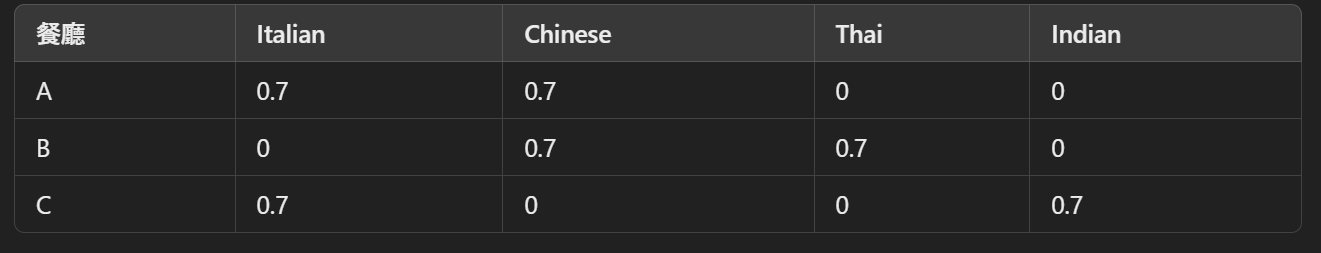

In [30]:
#Extracting Stopword
tfidf = TfidfVectorizer(stop_words='english')
#Replace NaN for empty string
data_sample['Split'] = data_sample['Split'].fillna('')
#Applying TF-IDF Vectorizer
tfidf_matrix = tfidf.fit_transform(data_sample['Split'])

C:\Users\wayne\AppData\Local\Temp\ipykernel_29596\825650822.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_sample['Split'] = data_sample['Split'].fillna('')


### Compute the cosine similarity matrix

In [33]:
cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix) 

### Constructing a reverse map of indices

In [36]:
# Column names are using for index
corpus_index=[n for n in data_sample['Split']]

#Construct a reverse map of indices    
indices = pd.Series(data_sample.index, index=data_sample['Restaurant Name']).drop_duplicates() 

# Collect index of the restaurant matches the cuisines of the title (restaurant)
title="Pizza Hut"
idx = indices[title]
#Aggregate rating added with cosine score in sim_score list.
sim_scores=[]
for i,j in enumerate(cosine_sim[idx]):
    k=data_sample['Aggregate rating'].iloc[i]
    if j != 0 :
        sim_scores.append((i,j,k))

### Sort the restaurant names based on the similarity scores

In [38]:
sim_scores = sorted(sim_scores, key=lambda x: (x[1],x[2]) , reverse=True)
# 10 similar cuisines
sim_scores = sim_scores[0:10]
rest_indices = [i[0] for i in sim_scores] 

### Display the restaurants

In [41]:
data_x =data_sample[['Restaurant Name','Aggregate rating']].iloc[rest_indices]
    
data_x['Cosine Similarity']=0
for i,j in enumerate(sim_scores):
    data_x['Cosine Similarity'].iloc[i]=round(sim_scores[i][1],2)
    
data_x

C:\Users\wayne\AppData\Local\Temp\ipykernel_29596\2281699144.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data_x['Cosine Similarity'].iloc[i]=round(sim_scores[i][1],2)
C:\Users\wayne\AppData\Local\Temp\ipykernel_29596\2281699144.py:5:

,Restaurant Name,Aggregate rating,Cosine Similarity
63,Pizza Hut,3.5,1.00
32,Domino's Pizza,3.7,0.90
91,Ovenstory Pizza,0.0,0.90
70,Sbarro,3.5,0.86
26,Caffe Tonino,3.9,0.68
83,The Rolling Joint,3.9,0.52
8,Indian Coffee House,3.3,0.52
58,Nizam's Kathi Kabab,3.8,0.45
82,The Luggage Room Kitchen And Bar,3.5,0.36
49,Life Caffe,3.6,0.36


### Putting all of the above logic inside a `restaurant_recommender( )` function

In [57]:
data_sample=[]
def restaurant_recommender(location,title):   
    global data_sample       
    global cosine_sim
    global sim_scores
    global tfidf_matrix
    global corpus_index
    global feature
    global rest_indices
    global idx
    
    # When location comes from function ,our new data consist only location dataset
    data_sample = data_new_delphi.loc[data_new_delphi['Locality'] == location]  
    
    # index will be reset for cosine similarty index because Cosine similarty index has to be same value with result of tf-idf vectorize
    data_sample.reset_index(level=0, inplace=True) 
    
    #Feature Extraction
    data_sample['Split']="X"
    for i in range(0,data_sample.index[-1]):
        split_data=re.split(r'[,]', data_sample['Cuisines'][i])
        for k,l in enumerate(split_data):
            split_data[k]=(split_data[k].replace(" ", ""))
        split_data=' '.join(split_data[:])
        data_sample['Split'].iloc[i]=split_data
        
    #TF-IDF vectorizer
    #Extracting Stopword
    tfidf = TfidfVectorizer(stop_words='english')
    #Replace NaN for empty string
    data_sample['Split'] = data_sample['Split'].fillna('')
    #Applying TF-IDF Vectorizer
    tfidf_matrix = tfidf.fit_transform(data_sample['Split'])
    
    feature = tfidf.get_feature_names_out()

    
    #Cosine Similarity
    # Compute the cosine similarity matrix
    cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix) 
    
    # Column names are using for index
    corpus_index=[n for n in data_sample['Split']]
       
    #Construct a reverse map of indices    
    indices = pd.Series(data_sample.index, index=data_sample['Restaurant Name']).drop_duplicates() 
    
    #index of the restaurant matchs the cuisines
    idx = indices[title]
    #Aggregate rating added with cosine score in sim_score list.
    sim_scores=[]
    for i,j in enumerate(cosine_sim[idx]):
        k=data_sample['Aggregate rating'].iloc[i]
        if j != 0 :
            sim_scores.append((i,j,k))
            
    #Sort the restaurant names based on the similarity scores
    sim_scores = sorted(sim_scores, key=lambda x: (x[1],x[2]) , reverse=True)
    # 10 similar cuisines
    sim_scores = sim_scores[0:10]
    rest_indices = [i[0] for i in sim_scores] 
  
    data_x =data_sample[['Restaurant Name','Aggregate rating']].iloc[rest_indices]
    
    data_x['Cosine Similarity']=0
    for i,j in enumerate(sim_scores):
        data_x['Cosine Similarity'].iloc[i]=round(sim_scores[i][1],2)
   
    return data_x

### Top 10 similar restaurant with cuisine of 'Pizza Hut' restaurant in Connaught Place

In [60]:
restaurant_recommender('Connaught Place','Pizza Hut')

C:\Users\wayne\AppData\Local\Temp\ipykernel_29596\1455225680.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_sample['Split']="X"
C:\Users\wayne\AppData\Local\Temp\ipykernel_29596\1455225680.py:25: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"]

,Restaurant Name,Aggregate rating,Cosine Similarity
63,Pizza Hut,3.5,1.00
32,Domino's Pizza,3.7,0.90
91,Ovenstory Pizza,0.0,0.90
70,Sbarro,3.5,0.86
26,Caffe Tonino,3.9,0.68
83,The Rolling Joint,3.9,0.52
8,Indian Coffee House,3.3,0.52
58,Nizam's Kathi Kabab,3.8,0.45
82,The Luggage Room Kitchen And Bar,3.5,0.36
49,Life Caffe,3.6,0.36


### Top 10 similar restaurant with cuisine of 'Barbeque Nation' restaurant in Connaught Place

In [62]:
restaurant_recommender('Connaught Place','Barbeque Nation')

C:\Users\wayne\AppData\Local\Temp\ipykernel_29596\1455225680.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_sample['Split']="X"
C:\Users\wayne\AppData\Local\Temp\ipykernel_29596\1455225680.py:25: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"]

,Restaurant Name,Aggregate rating,Cosine Similarity
96,Barbeque Nation,4.1,1.00
5,Delhi Darbar Dhaba,3.2,1.00
101,Fa Yian,4.0,0.84
30,China Garden,3.9,0.84
23,Cafe Hawkers,3.7,0.77
64,Playboy Cafe,3.7,0.77
61,Parikrama - The Revolving Restaurant,3.8,0.69
56,My Bar Headquarters,3.7,0.69
73,SSKY Bar & Lounge,3.5,0.69
0,Amber,2.6,0.69
